# Shared Memory Parallelism Using OpenMP
We want to use OpenMP to enable parallel execution of our codes. If multiple workers can do the same job, execution will be sped up.

In [1]:
export OMP_NUM_THREADS=10
export OMP_PROC_BIND=close
export OMP_PLACES=cores

In [2]:
pygmentize omp_examples/a01-parallel.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const *argv[]) {
  // this is a sequential region
  srand(712);
  double a = rand() % 100;
  std::cout << std::to_string(a) + "\n\n";

  // this is a parallel region
#pragma omp parallel
  {
    double b = rand() % 100;
    std::cout << std::to_string(b) + "\n";
  }

  // this is a sequential region
  std::cout << "\nthis is a sequential region again\n";

  std::cout << std::flush;
}


We need to tell the compiler that our program contains OpenMP pragmas with the `-fopenmp` option.

In [3]:
g++ omp_examples/a01-parallel.cpp -fopenmp -o parallel.out

Now we can run the generated executable.

In [4]:
./parallel.out

22.000000

38.000000
49.000000
31.000000
12.000000
76.000000
81.000000
2.000000
3.000000
65.000000
56.000000

this is a sequential region again


<div class="alert alert-block alert-warning">
    We see that each worker is entering the parallel region and executes the code independently of the other workers.<br>
    If we repeat the same block multiple times we see that there is no deterministic answer as the order changes. We see, though, that the numbers printed are always the same
</div>    

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>1.</b> Can you explain why the numbers are the same but the order is jumbled up?
    
<b>2.</b> Why do you see this number of output lines?
</div>

<b>ANSWERS</b><p>

1. We seed the random number generator, so each run produces the same set of random values. There is no guarantee for the order of operations though, so the lines can appear in a different order.
2. We have set the number of OpenMP threads to 10 using an environment variable at the very beginning of this notebook.

## Information About the Region
OpenMP provides runtime functions to query the current thread number and the number of threads in each parallel region.

In [5]:
pygmentize omp_examples/a02-infos.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {
#pragma omp parallel
  {
    int size = omp_get_num_threads();
    int rank = omp_get_thread_num();
#pragma omp critical(output)
    std::cout << "I am thread " << rank << " of a total of " << size << " threads" << std::endl;
  }
}


In [6]:
g++ omp_examples/a02-infos.cpp -fopenmp -o infos.out && ./infos.out

I am thread 0 of a total of 10 threads
I am thread 1 of a total of 10 threads
I am thread 2 of a total of 10 threads
I am thread 3 of a total of 10 threads
I am thread 4 of a total of 10 threads
I am thread 9 of a total of 10 threads
I am thread 5 of a total of 10 threads
I am thread 6 of a total of 10 threads
I am thread 7 of a total of 10 threads
I am thread 8 of a total of 10 threads


<div class="alert alert-block alert-warning">
    We can inspect the current thread number and the total number of threads via OpenMP runtime functions.
</div>    

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>3.</b> Can you think of a good reason why this information might be useful?
    
</div>

<b>ANSWERS</b><p>

3. There can be many reasons, such as:
- Each thread doing local work and storing it in its own element of an array.
- Threads working on local work having to communicate with neighboring threads

## Setting the Number of Threads
We can do this either on each parallel region or with an environment variable

In [7]:
pygmentize omp_examples/a03-threadnum.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

#pragma omp parallel num_threads(2)
  {
    int size = omp_get_num_threads();
    int rank = omp_get_thread_num();
#pragma omp critical(output)
    std::cout << "I am thread " << rank << " of a total of " << size << " threads" << std::endl;
  }
}


In [8]:
g++ omp_examples/a03-threadnum.cpp -fopenmp -o threadnum.out && ./threadnum.out

I am thread 0 of a total of 2 threads
I am thread 1 of a total of 2 threads


<div class="alert alert-block alert-warning">
    We can set the number of threads with the <code>num_threads</code> keyword for parallel regions
</div>

In [9]:
OMP_NUM_THREADS=4 ./infos.out

I am thread 0 of a total of 4 threads
I am thread 2 of a total of 4 threads
I am thread 1 of a total of 4 threads
I am thread 3 of a total of 4 threads


<div class="alert alert-block alert-warning">
    We can set the number of threads to use when nothing is specified with the <code>OMP_NUM_THREADS</code> environment variable.
</div>

In [10]:
OMP_NUM_THREADS=4 ./threadnum.out

I am thread 0 of a total of 2 threads
I am thread 1 of a total of 2 threads


<div class="alert alert-block alert-warning">
    We see that <code>num_threads</code> takes precedence over <code>OMP_NUM_THREADS</code>
</div>

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>4.</b> Why do you think num_threads is higher up in the order of precedence?<br>
<b>5.</b> Why do we need two ways of controlling this? Are these two ways fulfilling the same purpose?
</div>

<b>ANSWERS</b><p>

4. We can optimize certain codes for a fixed number of workers. If we have such a code, we do not want the environment to override this local choice.
5. We have more fine-grained control over the number of threads on a per-block basis compared to a global default value. 
    

## Parallel Loops
Since loops are such an important concept to parallelize, there is a special directive for it.

In [11]:
pygmentize omp_examples/a04-loops.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

// parallel loop
#pragma omp parallel for
  for(int i = 0; i < 10; ++i) {
#pragma omp critical(output)
    std::cout << "This is iteration " << i << " executed from thread " << omp_get_thread_num()
              << std::endl;
  }
}


In [12]:
g++ omp_examples/a04-loops.cpp -fopenmp -o loops.out

In [13]:
OMP_NUM_THREADS=4 ./loops.out

This is iteration 0 executed from thread 0
This is iteration 1 executed from thread 0
This is iteration 2 executed from thread 0
This is iteration 8 executed from thread 3
This is iteration 9 executed from thread 3
This is iteration 3 executed from thread 1
This is iteration 4 executed from thread 1
This is iteration 5 executed from thread 1
This is iteration 6 executed from thread 2
This is iteration 7 executed from thread 2


<div class="alert alert-block alert-warning">
    We see that the loop order is not preserved, threads take different number of iterations and are not sorted
</div>

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>6.</b> Since this is an existing concept it has its applications. Can you think of a simple example where the loop order does not matter? Can you also think of one where an unordered loop will break the program flow?<br>
    
</div>

<b>ANSWERS</b><p>

6. Examples are:
- Loop order doesn't matter: Any stencil computation. (The output is not the input)
- Loop order matters: For example the circuit value problem. For a set of circuits and a given input, generate the output.

In [14]:
OMP_NUM_THREADS=12 ./loops.out

This is iteration 0 executed from thread 0
This is iteration 1 executed from thread 1
This is iteration 2 executed from thread 2
This is iteration 9 executed from thread 9
This is iteration 4 executed from thread 4
This is iteration 3 executed from thread 3
This is iteration 5 executed from thread 5
This is iteration 6 executed from thread 6
This is iteration 7 executed from thread 7
This is iteration 8 executed from thread 8


<div class="alert alert-block alert-warning">
    If more threads than loop iterations are available, only the first set of threads is used
</div>

## Scheduling
<div class="alert alert-block alert-danger">
This is an important concept to understand but is not necessarily used in our example
</div>

Controlling loop execution with the `schedule` directive can be important for performance. Since the work per grid point is often similar in weather and climate codes, this is not central for our stencil example, but it is still a concept worth knowing.

In [15]:
pygmentize omp_examples/a05-schedule.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

  std::cout << "schedule(static, 2)" << std::endl;
#pragma omp parallel for schedule(static, 2)
  for(std::size_t i = 0; i < 10; ++i) {
#pragma omp critical(output)
    std::cout << "This is iteration " << i << " executed from thread " << omp_get_thread_num()
              << std::endl;
  }
  std::cout << "schedule(static, 1)" << std::endl;
#pragma omp parallel for schedule(static, 1)
  for(std::size_t i = 0; i < 10; ++i) {
#pragma omp critical(output)
    std::cout << "This is iteration " << i << " executed from thread " << omp_get_thread_num()
              << std::endl;
  }
}


In [16]:
g++ omp_examples/a05-schedule.cpp -fopenmp -o schedule.out

In [17]:
OMP_NUM_THREADS=2 ./schedule.out

schedule(static, 2)
This is iteration 0 executed from thread 0
This is iteration 1 executed from thread 0
This is iteration 4 executed from thread 0
This is iteration 5 executed from thread 0
This is iteration 8 executed from thread 0
This is iteration 9 executed from thread 0
This is iteration 2 executed from thread 1
This is iteration 3 executed from thread 1
This is iteration 6 executed from thread 1
This is iteration 7 executed from thread 1
schedule(static, 1)
This is iteration 1 executed from thread 1
This is iteration 3 executed from thread 1
This is iteration 5 executed from thread 1
This is iteration 7 executed from thread 1
This is iteration 9 executed from thread 1
This is iteration 0 executed from thread 0
This is iteration 2 executed from thread 0
This is iteration 4 executed from thread 0
This is iteration 6 executed from thread 0
This is iteration 8 executed from thread 0


<div class="alert alert-block alert-warning">
    Static scheduling allows us to assign chunks of loop iterations to the same thread.
</div>

## Variable Scoping
We try to understand how variables are scoped, who owns them at which parts of the code and who can see effects of writing them.

In [18]:
pygmentize omp_examples/a06-scoping.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

  int myvar = -1;
#pragma omp parallel for num_threads(3)
  for(std::size_t i = 0; i < 10; ++i) {
    myvar = i;
#pragma omp critical(output)
    std::cout << "i is " << i << " and myvar is " << myvar << std::endl;
  }

  std::cout << "myvar: " << myvar << std::endl;
}


In [19]:
g++ omp_examples/a06-scoping.cpp -fopenmp -o scoping.out

In [20]:
./scoping.out

i is 0 and myvar is 4
i is 1 and myvar is 1
i is 2 and myvar is 2
i is 3 and myvar is 3
i is 4 and myvar is 3
i is 5 and myvar is 5
i is 6 and myvar is 6
i is 7 and myvar is 6
i is 8 and myvar is 8
i is 9 and myvar is 9
myvar: 9


<div class="alert alert-block alert-warning">
    We see that shared variables can cause race conditions
</div>

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>7.</b> Run the above code 5 times. What do you observe?<br>
<b>8.</b> Why is the code above problematic? Is what we're doing here still compatible with the Turing Machine way of modelling computers?
    
</div>

<b>ANSWERS</b><p>

7. The output in the end is not deterministic.

8. We have no way of controlling which thread is the last to write output. So we have some inherent randomness and are therefore no longer fulfilling the requirement of having deterministic output from inputs.

The private directive allows each thread to have a copy of a variable: 

In [21]:
pygmentize omp_examples/a07-private.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>

int main(int argc, char const* argv[]) {

  int myvar = 42;
#pragma omp parallel for private(myvar)
  for(std::size_t i = 0; i < 10; ++i) {
#pragma omp critical(output)
    std::cout << "before writing:\n  i is " << i << " and myvar is " << myvar << std::endl;
    myvar = i;
#pragma omp critical(output)
    std::cout << "after writing:\n\ti is " << i << " and myvar is " << myvar << std::endl;
  }
  std::cout << "myvar: " << myvar << std::endl;
}


In [22]:
g++ omp_examples/a07-private.cpp -fopenmp -o private.out

In [23]:
OMP_NUM_THREADS=10 ./private.out

before writing:
  i is 0 and myvar is 0
after writing:
	i is 0 and myvar is 0
before writing:
  i is 2 and myvar is 0
after writing:
	i is 2 and myvar is 2
before writing:
  i is 1 and myvar is 0
after writing:
	i is 1 and myvar is 1
before writing:
  i is 4 and myvar is 0
after writing:
	i is 4 and myvar is 4
before writing:
  i is 3 and myvar is 0
after writing:
	i is 3 and myvar is 3
before writing:
  i is 9 and myvar is 0
after writing:
	i is 9 and myvar is 9
before writing:
  i is 5 and myvar is 0
before writing:
  i is 6 and myvar is 0
after writing:
	i is 5 and myvar is 5
after writing:
	i is 6 and myvar is 6
before writing:
  i is 8 and myvar is 0
before writing:
  i is 7 and myvar is 0
after writing:
	i is 8 and myvar is 8
after writing:
	i is 7 and myvar is 7
myvar: 42


<div class="alert alert-block alert-warning">
    We see:
    <ul>
        <li>Private variables are independent copies for each thread.</li>
        <li>Their initial value is undefined unless they are initialized inside the region or declared <code>firstprivate</code>.</li>
        <li>Private variables do not cause race conditions.</li>
        <li>The private values are not copied back after leaving the parallel region.</li>
    </ul>
</div>

shared is the default but can also be stated explicitly

In [24]:
pygmentize omp_examples/a08-shared.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

  int myvar = -1;
#pragma omp parallel for shared(myvar)
  for(std::size_t i = 0; i < 10; ++i) {
#pragma omp critical(output)
    std::cout << "before writing:\ni is " << i << " and myvar is " << myvar << std::endl;
    myvar = i;
#pragma omp critical(output)
    std::cout << "after writing:\n   i is " << i << " and myvar is " << myvar << std::endl;
  }
  std::cout << "myvar: " << myvar << std::endl;
}


In [25]:
g++ omp_examples/a08-shared.cpp -fopenmp -o shared.out

In [26]:
OMP_NUM_THREADS=10 ./shared.out

before writing:
i is 0 and myvar is -1
after writing:
   i is 0 and myvar is 0
before writing:
i is 5 and myvar is 0
after writing:
   i is 5 and myvar is 5
before writing:
i is 6 and myvar is 5
after writing:
   i is 6 and myvar is 6
before writing:
i is 3 and myvar is 6
after writing:
   i is 3 and myvar is 3
before writing:
i is 4 and myvar is 3
after writing:
   i is 4 and myvar is 4
before writing:
i is 1 and myvar is 4
after writing:
   i is 1 and myvar is 1
before writing:
i is 9 and myvar is 1
before writing:
i is 7 and myvar is 9
after writing:
   i is 9 and myvar is 7
before writing:
i is 2 and myvar is 7
before writing:
i is 8 and myvar is 2
after writing:
   i is 7 and myvar is 8
after writing:
   i is 8 and myvar is 8
after writing:
   i is 2 and myvar is 8
myvar: 8


<div class="alert alert-block alert-warning">
    We find a way to explicitly use shared variables in parallel regions
</div>

## Special Regions
<div class="alert alert-block alert-danger">
This is an important concept to understand but is not necessarily used in our example
</div>

There are certain pieces of the code that might be more sensitive to how threads should be handling them, here are the options:

In [27]:
pygmentize omp_examples/a09-regions.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

#pragma omp parallel
  {
    int size = omp_get_num_threads();
    int rank = omp_get_thread_num();
#pragma omp single
    {
      std::cout << "thread " << rank << " is present in single" << std::endl;
      std::cout << "and the size here is : " << omp_get_num_threads() << std::endl;
    }
#pragma omp master
    { std::cout << "thread " << rank << " is present in master" << std::endl; }
#pragma omp critical(somethingHard)
    { std::cout << "thread " << rank << " is present in critical" << std::endl; }
  }
}


In [28]:
g++ omp_examples/a09-regions.cpp -fopenmp -o regions.out && ./regions.out

thread 0 is present in single
and the size here is : 10
thread thread 05 is present in critical
thread 7 is present in critical
thread  is present in master8
 is present in critical
thread 6 is present in critical
thread 1 is present in critical
thread 3 is present in critical
thread 2 is present in critical
thread 4 is present in critical
thread 0 is present in critical
thread 9 is present in critical


<div class="alert alert-block alert-warning">
    We learn that thread 0 is the only one entering <code>master</code>, only one thread ever enters <code>single</code> and every thread enters <code>critical</code>, but only one at a time
</div>

## What if parallel regions span multiple tasks?
<div class="alert alert-block alert-danger">
This is an important concept to understand but is not necessarily used in our example
</div>

Depending on how the parallelization is structured, threads may need to wait for each other. The OpenMP barrier directive is used for that.

In [29]:
pygmentize omp_examples/a10-barrier.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

#pragma omp parallel num_threads(5)
  {
    int size = omp_get_num_threads();
    int rank = omp_get_thread_num();
#pragma omp critical(somethingHard)
    {
      std::string s = "thread " + std::to_string(rank) + " is present in critical1\n";
      std::cout << s;
    }
#pragma omp critical(somethingEasy)
    {
      std::string s = "thread " + std::to_string(rank) + " is present in critical2\n";
      std::cout << s;
    }
  }
}


In [30]:
g++ omp_examples/a10-barrier.cpp -fopenmp -o barrier.out && ./barrier.out

thread 0 is present in critical1
thread 0 is present in critical2
thread 3 is present in critical1
thread 3 is present in critical2
thread 4 is present in critical1
thread 4 is present in critical2
thread 1 is present in critical1
thread 1 is present in critical2
thread 2 is present in critical1
thread 2 is present in critical2


<div class="alert alert-block alert-warning">
    We learn that there is no guarantee on the execution order of different statements in a parallel block across threads
</div>

In [31]:
pygmentize omp_examples/a11-barrier.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

#pragma omp parallel num_threads(5)
  {
    int size = omp_get_num_threads();
    int rank = omp_get_thread_num();
#pragma omp critical(somethingHard)
    {
      std::string s = "thread " + std::to_string(rank) + " is present in critical1\n";
      std::cout << s;
    }
#pragma omp barrier
#pragma omp critical(somethingEasy)
    {
      std::string s = "thread " + std::to_string(rank) + " is present in critical2\n";
      std::cout << s;
    }
  }
}


In [32]:
g++ omp_examples/a11-barrier.cpp -fopenmp -o barrier2.out && ./barrier2.out

thread 0 is present in critical1
thread 1 is present in critical1
thread 2 is present in critical1
thread 4 is present in critical1
thread 3 is present in critical1
thread 4 is present in critical2
thread 2 is present in critical2
thread 0 is present in critical2
thread 1 is present in critical2
thread 3 is present in critical2


<div class="alert alert-block alert-warning">
    We learn that barriers help synchronize code
</div>

## Nowait
<div class="alert alert-block alert-danger">
This is an important concept to understand but is not necessarily used in our example
</div>

Certain OpenMP statements come with implicit barriers so `nowait` is the keyword to explicitly disable those

In [33]:
pygmentize omp_examples/a12-loops.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

#pragma omp parallel num_threads(3)
  {
    int size = omp_get_num_threads();
    int rank = omp_get_thread_num();
#pragma omp for
    for(int i = 0; i < 6; ++i) {
      std::string s = "loop 1, iteration" + std::to_string(i) + "\n";
      std::cout << s;
    }

#pragma omp for
    for(int i = 0; i < 6; ++i) {
      std::string s = "loop 2, iteration" + std::to_string(i) + "\n";
      std::cout << s;
    }
  }
}


In [34]:
g++ omp_examples/a12-loops.cpp -fopenmp -o loops.out && ./loops.out

loop 1, iteration0
loop 1, iteration1
loop 1, iteration4
loop 1, iteration5
loop 1, iteration2
loop 1, iteration3
loop 2, iteration4
loop 2, iteration5
loop 2, iteration0
loop 2, iteration1
loop 2, iteration2
loop 2, iteration3


<div class="alert alert-block alert-warning">
    We learn that OpenMP loop work-sharing constructs have an implicit barrier at the end by default.
</div>

In [35]:
pygmentize omp_examples/a13-nowait.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

#pragma omp parallel num_threads(3)
  {
    int size = omp_get_num_threads();
    int rank = omp_get_thread_num();
#pragma omp for nowait
    for(int i = 0; i < 6; ++i) {
      std::string s = "loop 1, iteration " + std::to_string(i) + "\n";
      std::cout << s;
    }

#pragma omp for nowait
    for(int i = 0; i < 6; ++i) {
      std::string s = "loop 2, iteration " + std::to_string(i) + "\n";
      std::cout << s;
    }
  }
}


In [36]:
g++ omp_examples/a13-nowait.cpp -fopenmp -o nowait.out && ./nowait.out

loop 1, iteration 0
loop 1, iteration 1
loop 2, iteration 0
loop 2, iteration 1
loop 1, iteration 4
loop 1, iteration 5
loop 2, iteration 4
loop 2, iteration 5
loop 1, iteration 2
loop 1, iteration 3
loop 2, iteration 2
loop 2, iteration 3


<div class="alert alert-block alert-warning">
    We learn that the <code>nowait</code> keyword can remove this implicit synchronization when it is safe to do so.
</div>

## Reductions
<div class="alert alert-block alert-danger">
This is an important concept to understand but is not necessarily used in our example
</div>

Since reductions are such an omnipresent motif, we do not want to implement it with critical / atomic every time, so there is a keyword for it:

In [37]:
pygmentize omp_examples/a14-reduction.cpp

#include <cstdlib>
#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {
  double sum = 0.0;
#pragma omp parallel for reduction(+ : sum)
  for(std::size_t t = 0; t < 10;++t) {
    sum += t;
  }
    std::cout << sum<<std::endl;
}


In [38]:
g++ omp_examples/a14-reduction.cpp -fopenmp -o reduction.out && ./reduction.out

45


<div class="alert alert-block alert-warning">
    We learn about the reduction keyword
</div>

# Amdahl's law

We try to investigate the performance of a simple example, computing $\pi$ using the Leibniz formula:

$$1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + \frac{1}{9} ... = \frac{\pi}{4}$$

Our goal is to understand what might affect performance and how this is reflected in strong and weak scaling plots

## Strong Scaling

Understanding how much faster the code gets through parallelization.

In [39]:
pygmentize omp_examples/b01-timing.cpp

#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

  int nThreads = atoi(argv[1]);
  omp_set_num_threads(nThreads);

  double tic = omp_get_wtime();

  int steps = 10000000;
  double sum = 0.0;
#pragma omp parallel for reduction(+ : sum)
  for(std::size_t t = 0; t < steps; ++t) {
    sum += (1.0 - 2 * (t % 2)) / (2 * t + 1);
  }

  double toc = omp_get_wtime();

#pragma omp parallel
  {
    if(omp_get_thread_num() == 0)
      std::cout << omp_get_num_threads() << "\t" << toc - tic << std::endl;
  }

  return 0;
}


In [40]:
g++ -fopenmp omp_examples/b01-timing.cpp -o timing.out

In [41]:
echo -n > out.txt
for nthread in `seq 12` ; do
  ./timing.out $nthread >> out.txt
done

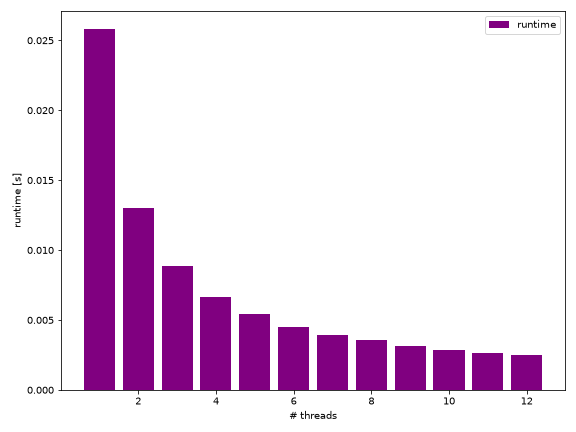

In [42]:
python -c "
import matplotlib
matplotlib.use('Agg')
import numpy as np, matplotlib.pyplot as plt;
data = np.loadtxt('out.txt');
threads = data[:,0].astype(int); runtimes = data[:,1];
plt.figure(figsize=(8,6));
plt.bar(threads, runtimes, color='purple', label='runtime');
plt.xlabel('# threads'); plt.ylabel('runtime [s]'); plt.legend(); plt.tight_layout();
plt.savefig('out.png', dpi=72)
"

cat out.png | display

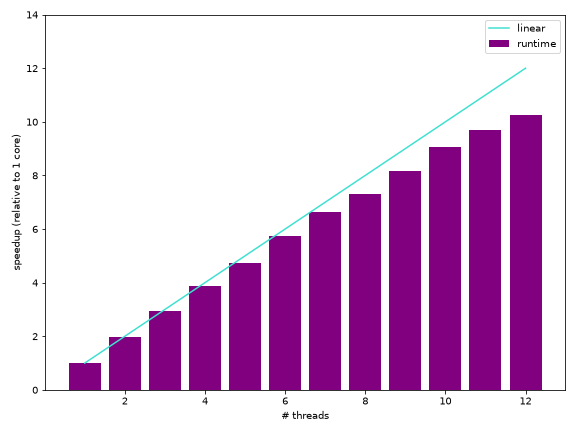

In [43]:
python -c "
import matplotlib
matplotlib.use('Agg')
import numpy as np, matplotlib.pyplot as plt
data = np.loadtxt('out.txt')
threads = data[:, 0].astype(int)
runtimes = data[:, 1]
base_runtime = runtimes[0]
speedup = base_runtime / runtimes
linear = threads
plt.figure(figsize=(8,6))
plt.bar(threads, speedup, color='purple', label='runtime')
plt.plot(threads, linear, color='turquoise', label='linear')
plt.xlabel('# threads')
plt.ylabel('speedup (relative to 1 core)')
plt.ylim(0, 14)
plt.legend()
plt.tight_layout()
plt.savefig('out.png', dpi=72)
"

cat out.png | display

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>9.</b> Can you explain the performance numbers that we see here? What effects are in place?<br>    
</div>

<b>ANSWERS</b><p>

9. The code is not perfectly parallel: creating threads, scheduling loop work, and combining the partial reduction results all add overhead. Therefore, the speedup cannot be perfectly linear.


## Weak scaling
Measuring whether runtime stays constant as we increase the problem size and the number of threads together.

In [44]:
pygmentize omp_examples/b02-weakscaling.cpp

#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

  int nThreads = atoi(argv[1]);
  int steps = 10000000 * nThreads;
  double sum = 0.0;

  omp_set_num_threads(nThreads);

  double tic = omp_get_wtime();

#pragma omp parallel for reduction(+ : sum)
  for(std::size_t t = 0; t < steps; ++t) {
    sum += (1.0 - 2 * (t % 2)) / (2 * t + 1);
  }

  double toc = omp_get_wtime();

#pragma omp parallel
  {
    if(omp_get_thread_num() == 0)
      std::cout << omp_get_num_threads() << "\t" << toc - tic << std::endl;
  }

  return 0;
}


In [45]:
g++ -fopenmp omp_examples/b02-weakscaling.cpp -o weak.out

In [46]:
echo -n > weak.txt
for nthread in `seq 72` ; do
    ./weak.out $nthread >> weak.txt
done

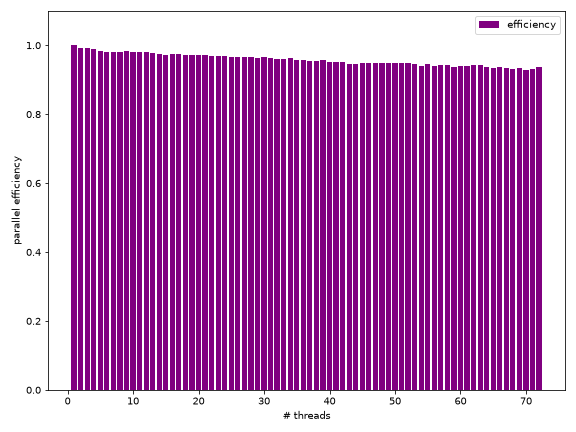

In [47]:
python -c "
import matplotlib
matplotlib.use('Agg')
import numpy as np, matplotlib.pyplot as plt
data = np.loadtxt('weak.txt')
threads = data[:, 0].astype(int)
runtimes = data[:, 1]
base_runtime = runtimes[0]
efficiency = (base_runtime / runtimes)
plt.figure(figsize=(8,6))
plt.bar(threads, efficiency, color='purple', label='efficiency')
plt.xlabel('# threads')
plt.ylabel('parallel efficiency')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig('out.png', dpi=72)
"

cat out.png | display

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>10.</b> Can you explain the performance numbers that we see here? What effects are in place?<br>
</div>

<b>ANSWERS</b><p>

10. Continually increasing overhead from OpenMP as we increase the number of threads. There is also some noise from other processes running on the CPU (such as the JupyterHub environment).


## Caching

Here we see the implication of caching in a multithreaded environment

In [48]:
pygmentize omp_examples/b03-caching.cpp

#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const* argv[]) {

  std::vector<double> input(10000000, 1);
  std::vector<double> output(10000000, 0);

  omp_set_num_threads(atoi(argv[1]));

  double tic = omp_get_wtime();

#pragma omp parallel for schedule(static, 1)
  for(int i = 0; i < input.size(); ++i) {
    output[i] = 2 * input[i];
    input[i] = 0;
  }

  double toc = omp_get_wtime();

#pragma omp parallel
  {
    if(omp_get_thread_num() == 0)
      std::cout << omp_get_num_threads() << "\t" << toc - tic << std::endl;
  }

  return 0;
}


In [49]:
g++ -fopenmp omp_examples/b03-caching.cpp -o caching.out

In [50]:
echo -n > caching.txt
for nthread in `seq 72` ; do
  ./caching.out $nthread >> caching.txt
done

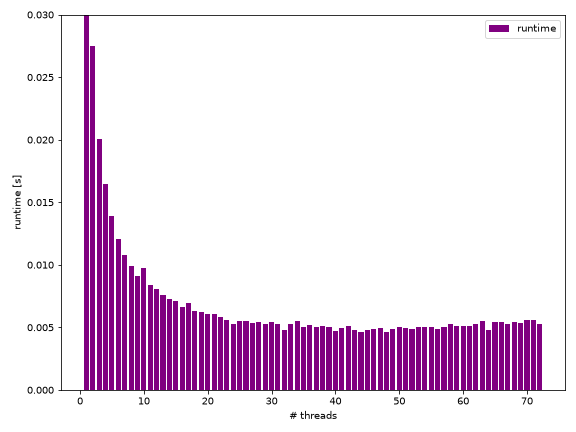

In [51]:
python -c "
import matplotlib
matplotlib.use('Agg')
import numpy as np, matplotlib.pyplot as plt
data = np.loadtxt('caching.txt')
threads = data[:, 0].astype(int)
runtimes = data[:, 1]
plt.figure(figsize=(8,6))
plt.bar(threads, runtimes, color='purple', label='runtime')
plt.xlabel('# threads')
plt.ylabel('runtime [s]')
plt.ylim(0, 0.03)
plt.legend()
plt.tight_layout()
plt.savefig('out.png', dpi=72)
"

cat out.png | display

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>11.</b> Can you explain the performance numbers that we see here? What effects are in place?<br>
</div>

<b>ANSWERS</b><p>

11. Each thread updates input(i) (writes) and reads input(i) for the computation. With schedule(static, 1) adjacent iterations are assigned to different threads in a round-robin fashion (e.g. thread 0 does i=1, thread 1 does i=2, etc.). Since arrays are stored contiguously in memory, different threads will write to elements of input() which reside on the same cache line. This causes false sharing, where cache lines are forced to be invalidated and updated across cores. Also, schedule(static, 1) assigns one iteration at a time, which will lead to a large synchronization overhead when increasing the number of threads.

In [52]:
pygmentize omp_examples/b04-caching_fast.cpp

#include <iostream>
#include <omp.h>
#include <vector>

int main(int argc, char const *argv[]) {

  std::vector<double> input(10000000, 1);
  std::vector<double> output(10000000, 0);

  omp_set_num_threads(atoi(argv[1]));

  double tic = omp_get_wtime();

#pragma omp parallel for schedule(static, 10000)
  for (int i = 0; i < input.size(); ++i) {
    output[i] = 2 * input[i];
    input[i] = 0;
  }

  double toc = omp_get_wtime();

#pragma omp parallel
  {
    if (omp_get_thread_num() == 0)
      std::cout << omp_get_num_threads() << "\t" << toc - tic << std::endl;
  }

  return 0;
}


In [53]:
g++ -fopenmp omp_examples/b04-caching_fast.cpp -o caching2.out

In [54]:
echo -n > caching2.txt
for nthread in `seq 72` ; do
  ./caching2.out $nthread >> caching2.txt
done

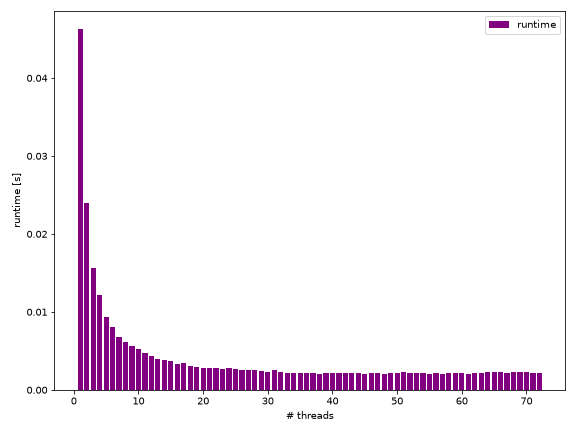

In [55]:
python -c "
import matplotlib
matplotlib.use('Agg')
import numpy as np, matplotlib.pyplot as plt
data = np.loadtxt('caching2.txt')
threads = data[:, 0].astype(int)
runtimes = data[:, 1]
plt.figure(figsize=(8,6))
plt.bar(threads, runtimes, color='purple', label='runtime')
plt.xlabel('# threads')
plt.ylabel('runtime [s]')
#plt.ylim(0, 0.03)
plt.legend()
plt.tight_layout()
plt.savefig('out.png', dpi=72)
"

cat out.png | display

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>12.</b> Can you explain the performance numbers that we see here? What effects are in place?<br>
</div>

<b>ANSWERS</b><p>

12. Using a static scheduler with larger chunks allows us to keep entire cache lines in our caches before they get invalidated. This gives much better performance and scalability: using more threads is significantly better than it was before. Since our code is memory-bandwidth bound, at some point the memory bandwidth is saturated and adding more threads does not increase the performance of our program.

In [56]:
make clean_examples

rm -f *.out weak.txt caching.txt caching2.txt out.txt out.png
